In [2]:
import networkx as nx
import numpy as np
import ast
import re
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns

# Data Understanding - Message Quality Audit

In [3]:
# Caricamento grafo e estrazione di tutti i commenti
INPUT_FILE = "private/dataset_roberta_final.gexf"

G = nx.read_gexf(INPUT_FILE)
print(f"Nodi: {G.number_of_nodes()}, Archi: {G.number_of_edges()}, Diretto: {G.is_directed()}")

all_comments = []
for u, v, data in G.edges(data=True):
    try:
        cl = ast.literal_eval(data.get('comments_list', '[]'))
    except Exception:
        cl = []
    all_comments.extend(cl)

print(f"Commenti totali estratti: {len(all_comments)}")

Nodi: 10855, Archi: 14011, Diretto: True
Commenti totali estratti: 14454


## Comment Length Statistics

In [4]:
lengths = [len(c.strip()) for c in all_comments]

print("--- Comment length stats ---")
print(f"Min:    {np.min(lengths)}")
print(f"Max:    {np.max(lengths)}")
print(f"Mean:   {np.mean(lengths):.1f}")
print(f"Median: {np.median(lengths):.1f}")
print()
print(f"< 10 chars:  {sum(1 for l in lengths if l < 10):>5} ({sum(1 for l in lengths if l < 10)/len(lengths)*100:.1f}%)")
print(f"< 20 chars:  {sum(1 for l in lengths if l < 20):>5} ({sum(1 for l in lengths if l < 20)/len(lengths)*100:.1f}%)")
print(f"< 50 chars:  {sum(1 for l in lengths if l < 50):>5} ({sum(1 for l in lengths if l < 50)/len(lengths)*100:.1f}%)")
print(f">= 50 chars: {sum(1 for l in lengths if l >= 50):>5} ({sum(1 for l in lengths if l >= 50)/len(lengths)*100:.1f}%)")

--- Comment length stats ---
Min:    5
Max:    335
Mean:   98.6
Median: 71.0

< 10 chars:    452 (3.1%)
< 20 chars:   1513 (10.5%)
< 50 chars:   5167 (35.7%)
>= 50 chars:  9287 (64.3%)


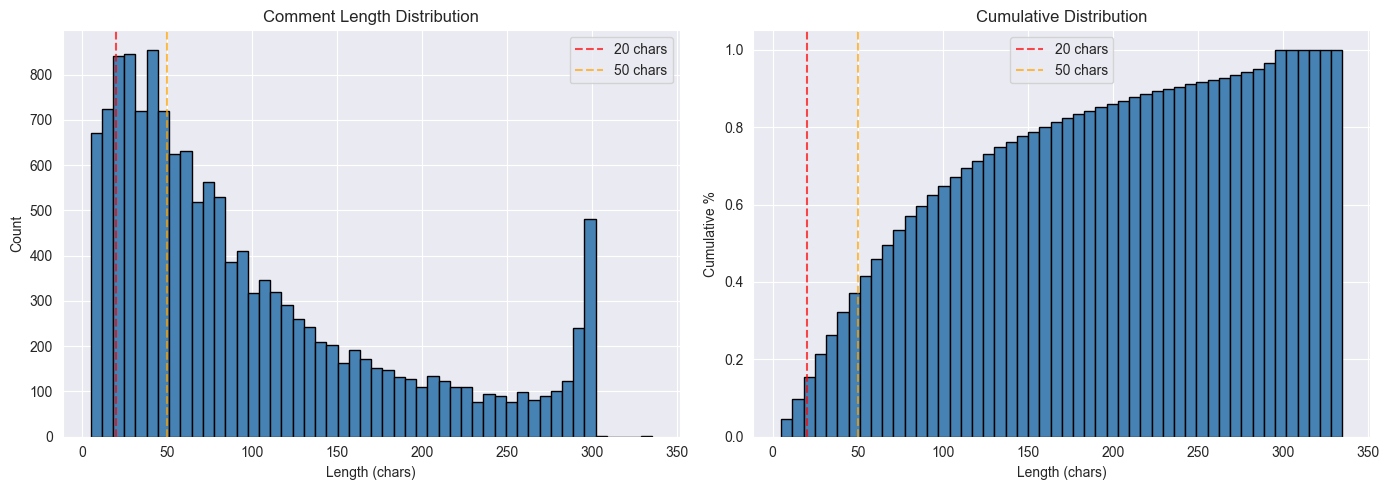

In [5]:
# Length distribution histogram
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(lengths, bins=50, color='steelblue', edgecolor='black')
axes[0].set_title("Comment Length Distribution")
axes[0].set_xlabel("Length (chars)")
axes[0].set_ylabel("Count")
axes[0].axvline(20, color='red', linestyle='--', alpha=0.7, label='20 chars')
axes[0].axvline(50, color='orange', linestyle='--', alpha=0.7, label='50 chars')
axes[0].legend()

axes[1].hist(lengths, bins=50, color='steelblue', edgecolor='black', cumulative=True, density=True)
axes[1].set_title("Cumulative Distribution")
axes[1].set_xlabel("Length (chars)")
axes[1].set_ylabel("Cumulative %")
axes[1].axvline(20, color='red', linestyle='--', alpha=0.7, label='20 chars')
axes[1].axvline(50, color='orange', linestyle='--', alpha=0.7, label='50 chars')
axes[1].legend()

plt.tight_layout()
plt.show()

## Noise Detection

In [6]:
# Emoji/symbol-only messages (< 3 alphanumeric chars)
emoji_heavy = [c for c in all_comments if len(re.sub(r'[^\w\s]', '', c.strip())) < 3]

# Single-word comments
single_word = [c for c in all_comments if len(c.strip().split()) == 1]

# Filler/agreement-only
filler_words = {'exactly', 'true', 'truth', 'yes', 'yep', 'yup', 'right', 'agreed',
                'same', 'this', 'good', 'nice', 'wow', 'amen', 'lol', 'lmao', 'haha'}
filler = [c for c in all_comments if c.strip().lower().rstrip('!.,') in filler_words]

# URL-containing
has_url = [c for c in all_comments if re.search(r'https?://|\.com/|\.org/', c)]

# Duplicates
comment_counts = Counter(all_comments)
duplicates = {text: count for text, count in comment_counts.items() if count > 1}
dup_total = sum(duplicates.values())

# Non-ASCII-heavy (likely emoji-only or non-English)
non_ascii = [c for c in all_comments if sum(1 for ch in c if ord(ch) < 128) / max(len(c), 1) < 0.5]

# Substantive
substantive = [c for c in all_comments if len(c.strip()) >= 50 and not re.match(r'^https?://\S+$', c.strip())]

n = len(all_comments)
print(f"{'Category':<40} {'Count':>6} {'%':>7}")
print("-" * 55)
print(f"{'Total comments':<40} {n:>6} {'100.0':>7}")
print(f"{'Substantive (>= 50 chars, not URL-only)':<40} {len(substantive):>6} {len(substantive)/n*100:>6.1f}%")
print(f"{'Short but valid (20-50 chars)':<40} {sum(1 for l in lengths if 20 <= l < 50):>6} {sum(1 for l in lengths if 20 <= l < 50)/n*100:>6.1f}%")
print(f"{'Very short (< 20 chars)':<40} {sum(1 for l in lengths if l < 20):>6} {sum(1 for l in lengths if l < 20)/n*100:>6.1f}%")
print()
print(f"{'Emoji/symbol-only':<40} {len(emoji_heavy):>6} {len(emoji_heavy)/n*100:>6.1f}%")
print(f"{'Single-word comments':<40} {len(single_word):>6} {len(single_word)/n*100:>6.1f}%")
print(f"{'Filler/agreement-only':<40} {len(filler):>6} {len(filler)/n*100:>6.1f}%")
print(f"{'Duplicated texts (total occurrences)':<40} {dup_total:>6} {dup_total/n*100:>6.1f}%")
print(f"{'URL-containing':<40} {len(has_url):>6} {len(has_url)/n*100:>6.1f}%")
print(f"{'Non-ASCII-heavy':<40} {len(non_ascii):>6} {len(non_ascii)/n*100:>6.1f}%")

Category                                  Count       %
-------------------------------------------------------
Total comments                            14454   100.0
Substantive (>= 50 chars, not URL-only)    9287   64.3%
Short but valid (20-50 chars)              3654   25.3%
Very short (< 20 chars)                    1513   10.5%

Emoji/symbol-only                            82    0.6%
Single-word comments                        578    4.0%
Filler/agreement-only                        60    0.4%
Duplicated texts (total occurrences)        405    2.8%
URL-containing                              268    1.9%
Non-ASCII-heavy                              86    0.6%


## Samples Inspection

In [7]:
# 20 shortest comments
print("--- 20 shortest comments ---")
sorted_comments = sorted(all_comments, key=lambda x: len(x.strip()))
for c in sorted_comments[:20]:
    print(f"  [{len(c.strip()):3d}] {repr(c.strip())}")

--- 20 shortest comments ---
  [  5] '🙏🙏🙏🙏🙏'
  [  5] 'Amen!'
  [  5] 'Good!'
  [  5] 'Never'
  [  5] 'right'
  [  5] 'Good.'
  [  5] 'AMF!!'
  [  5] '"too"'
  [  5] 'Truth'
  [  5] '👍🏼💯👍🏼'
  [  5] 'Truth'
  [  5] 'Truth'
  [  5] 'typo?'
  [  5] 'Chup.'
  [  5] 'Moron'
  [  5] 'None?'
  [  5] 'True.'
  [  5] 'Yup!!'
  [  5] '🤦🏾\u200d♂️'
  [  5] 'GOOD!'


In [8]:
# Top 15 most repeated comments
print("--- Top 15 most repeated comments ---")
for text, count in Counter(all_comments).most_common(15):
    print(f"  [{count}x] {repr(text[:100])}")

--- Top 15 most repeated comments ---
  [10x] 'No economy can thrive if society is plagued by the fear of losing freedom,by discrimination based on'
  [7x] 'Exactly'
  [6x] 'For those of you who remember my post about Jay Megan on TikTok, I want to inform you that she has m'
  [6x] 'bsky.app/profile/did:...'
  [5x] 'donald-von-shitsinpantz.urbanup.com/18075234'
  [5x] 'Good.'
  [5x] 'Exactly.'
  [5x] 'Attack RuZZia and the Orange Rent Boy everywhere..'
  [5x] 'Exactly!'
  [4x] 'Republicans deserve to be disemboweled in the midterms.'
  [4x] 'Release the Trump-Epstein Files. Stop the cover-up. Trump is an insane racist and a pedophile.'
  [4x] 'Agreed.'
  [4x] 'Concentration camps'
  [4x] 'Republicans rape kids. Democrats feed kids. NOT THE SAME. FDT - 86 47 - DJT=POS - Fuck MAGA - GOP=Gu'
  [4x] 'Nope.'


In [9]:
# Sample of emoji/symbol-only comments
print("--- Emoji/symbol-only samples ---")
for c in emoji_heavy[:10]:
    print(f"  {repr(c.strip())}")

print()

# Sample of non-ASCII-heavy comments
print("--- Non-ASCII-heavy samples ---")
for c in non_ascii[:10]:
    print(f"  {repr(c.strip()[:80])}")

--- Emoji/symbol-only samples ---
  '☝🏻☝🏽☝🏾☝🏿☝️'
  '🙏🙏🙏🙏🙏'
  '😃😄😁😆😅🤣'
  '👍🏼💯👍🏼'
  '😵\u200d💫😵\u200d💫😵\u200d💫'
  '😂😂😂😂😂😂😂😂😂😂😂😂😂😂'
  '🤣🤣🤣🤣🤣🤣🤣🤣🤣'
  '🤣🤣🤣🤣🤣🤣🤣'
  '🖕🖕🖕🖕🖕🖕🖕🖕🖕'
  '🤦🏻\u200d♂️😂'

--- Non-ASCII-heavy samples ---
  '☝🏻☝🏽☝🏾☝🏿☝️'
  '🙏🙏🙏🙏🙏'
  '👏🏻👏🏻👏🏻 Perfect‼️‼️‼️'
  'AMEN!\n👏👏👏👏👏👏👏👏👏👏👏'
  '😃😄😁😆😅🤣'
  '👍🏼💯👍🏼'
  '😵\u200d💫😵\u200d💫😵\u200d💫'
  '😂😂😂😂😂😂😂😂😂😂😂😂😂😂'
  '🤣🤣🤣🤣🤣🤣🤣🤣🤣'
  '🤣🤣🤣🤣🤣🤣🤣'


## Edge Weight Distribution

Comments per edge - Min: 1.0, Max: 9.0, Mean: 1.03, Median: 1
Edges with 1 comment:  13619 (97.2%)
Edges with 2+ comments: 392 (2.8%)
Edges with 5+ comments: 1 (0.0%)


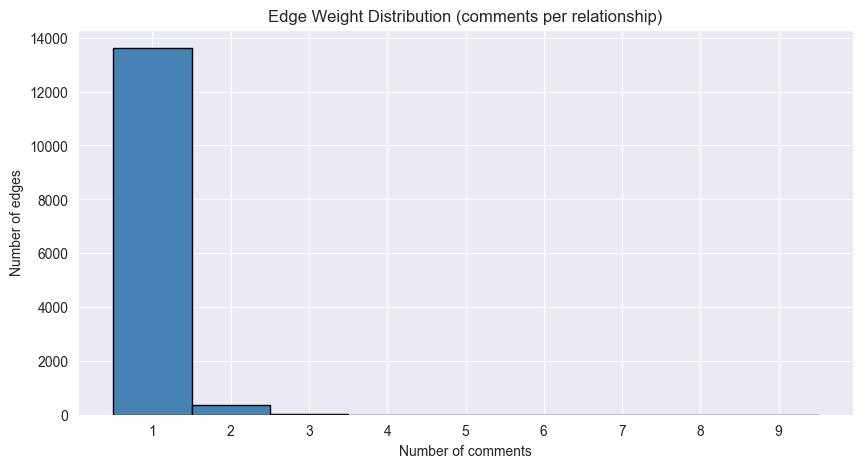

In [18]:
# How many comments per edge (relationship)
weights = [data.get('weight', 1) for u, v, data in G.edges(data=True)]
weights = [int(w) if isinstance(w, str) else w for w in weights]

print(f"Comments per edge - Min: {min(weights)}, Max: {max(weights)}, Mean: {np.mean(weights):.2f}, Median: {np.median(weights):.0f}")
print(f"Edges with 1 comment:  {sum(1 for w in weights if w == 1)} ({sum(1 for w in weights if w == 1)/len(weights)*100:.1f}%)")
print(f"Edges with 2+ comments: {sum(1 for w in weights if w >= 2)} ({sum(1 for w in weights if w >= 2)/len(weights)*100:.1f}%)")
print(f"Edges with 5+ comments: {sum(1 for w in weights if w >= 5)} ({sum(1 for w in weights if w >= 5)/len(weights)*100:.1f}%)")

plt.figure(figsize=(10, 5))

int_list = [round(x) for x in weights]

plt.hist(weights, bins=range(1, max(int_list) + 2), color='steelblue', edgecolor='black', align='left')
plt.title("Edge Weight Distribution (comments per relationship)")
plt.xlabel("Number of comments")
plt.ylabel("Number of edges")
plt.xticks(range(1, min(max(int_list) + 1, 20)))
plt.show()

## Sentiment Distribution

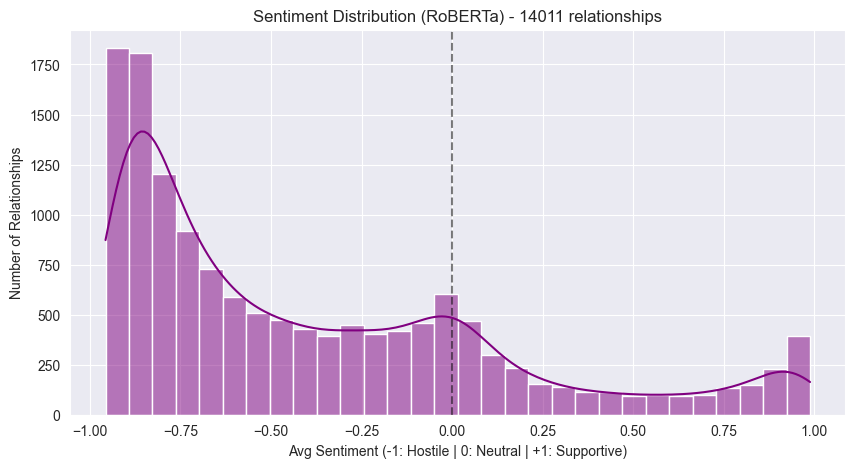

Mean sentiment:   -0.3932
Median sentiment: -0.5759
Std deviation:    0.5255
Very negative (<-0.5): 7598
Neutral (-0.2 to 0.2): 2567
Very positive (>0.5):  1249


In [19]:
sentiments = [float(data.get('sentiment_roberta', 0)) for u, v, data in G.edges(data=True)]

plt.figure(figsize=(10, 5))
sns.histplot(sentiments, bins=30, kde=True, color='purple')
plt.title(f"Sentiment Distribution (RoBERTa) - {len(sentiments)} relationships")
plt.xlabel("Avg Sentiment (-1: Hostile | 0: Neutral | +1: Supportive)")
plt.ylabel("Number of Relationships")
plt.axvline(0, color='black', linestyle='--', alpha=0.5)
plt.show()

print(f"Mean sentiment:   {np.mean(sentiments):.4f}")
print(f"Median sentiment: {np.median(sentiments):.4f}")
print(f"Std deviation:    {np.std(sentiments):.4f}")
print(f"Very negative (<-0.5): {sum(1 for x in sentiments if x < -0.5)}")
print(f"Neutral (-0.2 to 0.2): {sum(1 for x in sentiments if -0.2 <= x <= 0.2)}")
print(f"Very positive (>0.5):  {sum(1 for x in sentiments if x > 0.5)}")

In [22]:
import emoji
print(emoji.demojize('Python is 👍🏼💯👍🏼'))

Python is :thumbs_up_medium-light_skin_tone::hundred_points::thumbs_up_medium-light_skin_tone:
